In [3]:
import numpy as np
import pandas as pd

In [16]:
df=pd.read_csv('spam.csv' , encoding='latin-1')
df.head()
df.shape

(5572, 5)

## data cleaning

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [18]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
df.rename(columns={'v1':'target','v2':'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
from sklearn.preprocessing import LabelEncoder
en=LabelEncoder()
df['target']=en.fit_transform(df['target'])
df.sample(5)

,target,text
2346,0,Its posible dnt live in &lt;#&gt; century cm ...
2290,0,"HEY THERE BABE, HOW U DOIN? WOT U UP 2 2NITE L..."
194,0,How are you doing? Hope you've settled in for ...
4160,1,Had your mobile 11 months or more? U R entitle...
1798,0,That one week leave i put know that time. Why.


In [25]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [27]:
df.duplicated().sum()
df=df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

### EDA

In [29]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [31]:
import matplotlib.pyplot as plt

[]

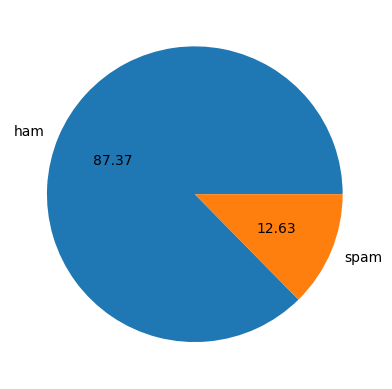

In [33]:
plt.pie(x=df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.plot()   #data is imbalance

In [34]:
!pip install nltk

In [98]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [90]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Ahmad
[nltk_data]     Nawaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ahmad
[nltk_data]     Nawaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ahmad
[nltk_data]     Nawaz\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [60]:
df['num_characters']=df['text'].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [63]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [64]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [68]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()  #ham messages

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [69]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe() #spam messages

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [70]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

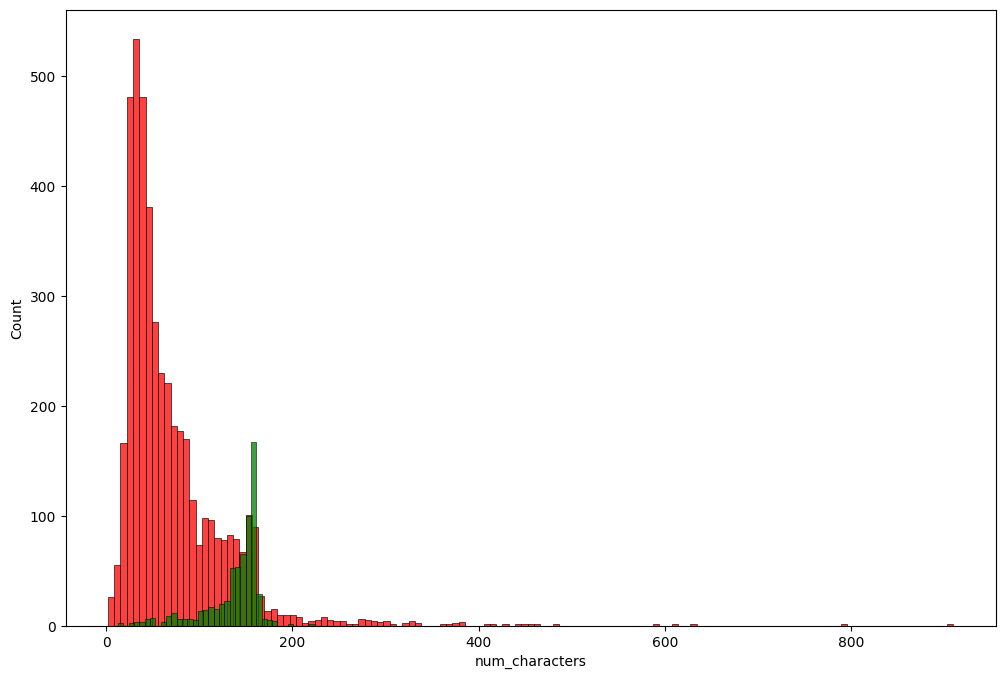

In [73]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_characters'] , color='red')
sns.histplot(df[df['target']==1]['num_characters'] , color='green')

<Axes: xlabel='num_words', ylabel='Count'>

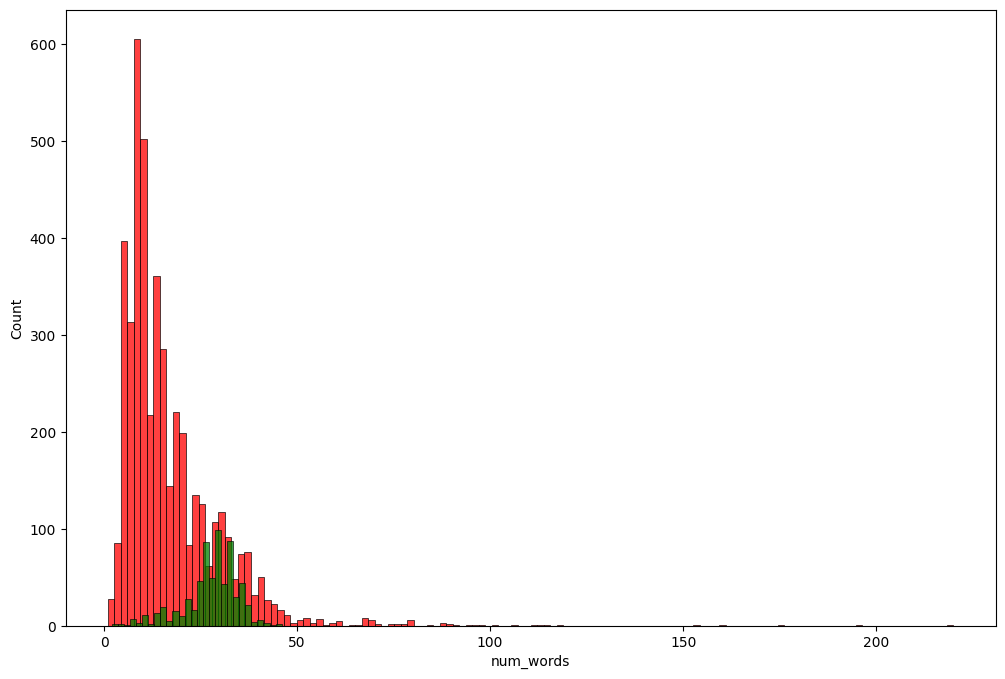

In [74]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_words'] , color='red')
sns.histplot(df[df['target']==1]['num_words'] , color='green')

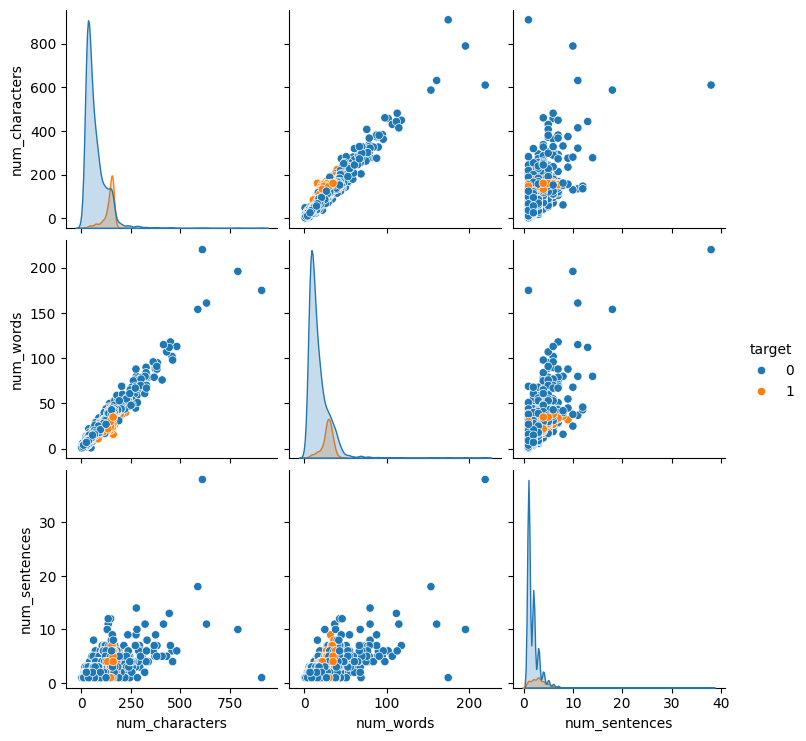

In [75]:
sns.pairplot(df,hue='target')

<Axes: >

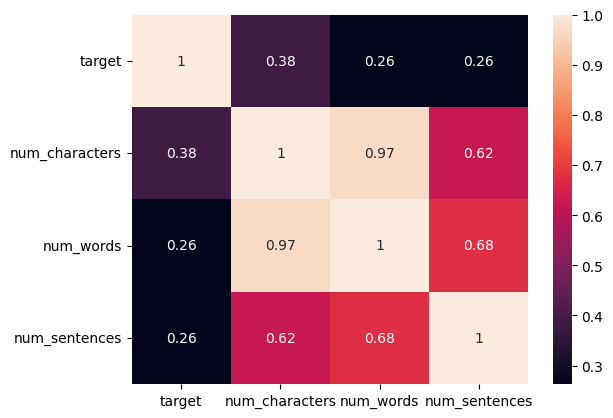

In [79]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data Prepocessing Txt

In [99]:
def trans_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [102]:
trans_text(df['text'][785])

'suppos could make still town though'

In [104]:
df['transformed_text']=df['text'].apply(trans_text)

In [105]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [124]:
from wordcloud import WordCloud
wc=WordCloud(width=1000,height=600,min_font_size=10,background_color='white')

In [125]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

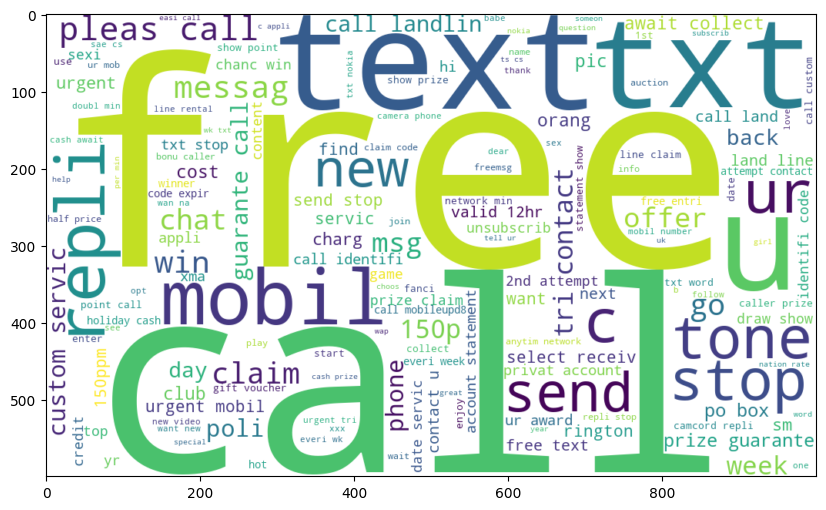

In [128]:
plt.figure(figsize=(10, 6))
plt.imshow(spam_wc , interpolation="bilinear")
plt.show()

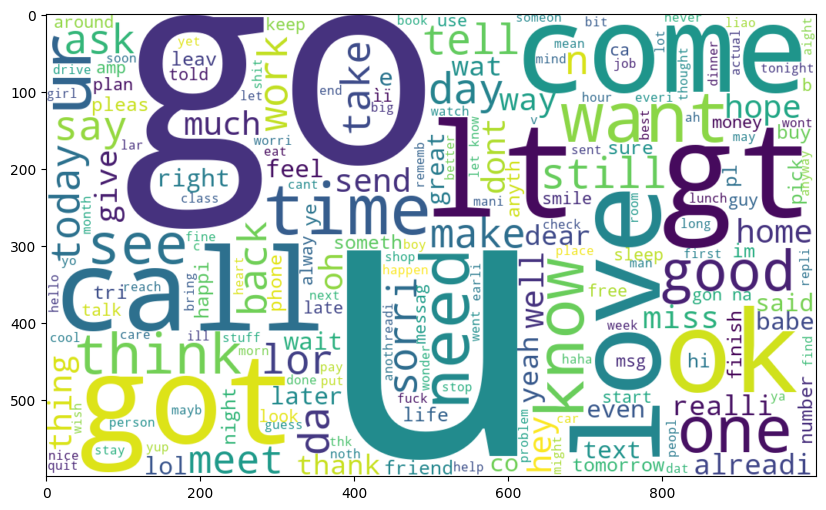

In [129]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 6))
plt.imshow(spam_wc , interpolation="bilinear")
plt.show()

In [130]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [146]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [147]:
len(spam_corpus)

9939

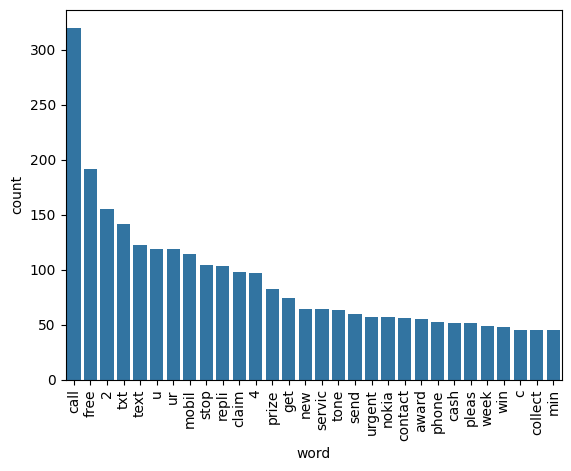

In [148]:
from collections import Counter
spamcount_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=spamcount_df)
plt.xticks(rotation='vertical')
plt.show()

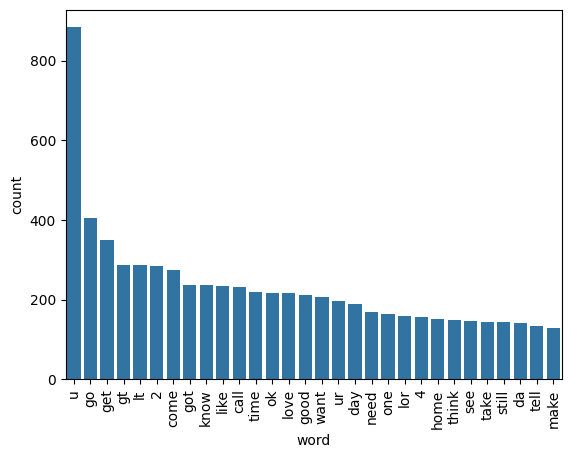

In [149]:
from collections import Counter
hamcount_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(x='word', y='count', data=hamcount_df)
plt.xticks(rotation='vertical')
plt.show()

## Model Building

In [179]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [180]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [181]:
X.shape
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [182]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [183]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2 , random_state=2)

In [184]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [185]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print('accuracy score = ', accuracy_score(y_test,y_pred1))
print('confusion matrix = ',confusion_matrix(y_test,y_pred1))
print('precision score =', precision_score(y_test,y_pred1))

accuracy score =  0.8694390715667312
confusion matrix =  [[788 108]
 [ 27 111]]
precision score = 0.5068493150684932


In [186]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print('accuracy score = ', accuracy_score(y_test,y_pred2))
print('confusion matrix = ',confusion_matrix(y_test,y_pred2))
print('precision score =', precision_score(y_test,y_pred2))

accuracy score =  0.9709864603481625
confusion matrix =  [[896   0]
 [ 30 108]]
precision score = 1.0


In [187]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print('accuracy score = ', accuracy_score(y_test,y_pred3))
print('confusion matrix = ',confusion_matrix(y_test,y_pred3))
print('precision score =', precision_score(y_test,y_pred3))

accuracy score =  0.9835589941972921
confusion matrix =  [[895   1]
 [ 16 122]]
precision score = 0.991869918699187


In [189]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
pickle.dump(trans_text,open('transform_text.pkl','wb'))